<a href="https://colab.research.google.com/github/Eshaal356/flyrank-ml-internship/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Search Intelligence & Content Opportunity Scoring
## FlyRank ML Internship Capstone

**Research lane:** Refresh / Content Opportunity Scoring

### Research objective

This study investigates whether a leakage-controlled set of content, search-demand, competition, freshness, and content-production signals can explain observed content momentum and support a transparent prioritization framework for human content review.

---

### Research-grade design principles

1. The target is audited before modeling.
2. Features that directly encode the target are removed.
3. Client identifiers are used only for grouped validation, never as predictors.
4. Missing-value treatment is learned inside pipelines, after the split.
5. Grouped train/test validation is the primary evaluation design because multiple observations belong to the same anonymized client.
6. A simple dummy baseline is mandatory.
7. Model performance is reported on untouched test data.
8. Predictive modeling and exploratory opportunity ranking are explicitly separated.
9. No causal, Google-algorithm, or guaranteed future-performance claim is made.
10. All recommendation labels are framed as review priorities, not autonomous actions.

**Important dataset finding:** `trend_pct` is mathematically equivalent to impression growth from `impressions_last_30d` versus `impressions_prev_30d` wherever the previous-period denominator is non-zero. Therefore those fields, and other direct target-derived fields, are excluded from the predictive feature matrix to prevent target leakage.


# 0. Reproducibility, Imports & Global Configuration

In [1]:
# ============================================================
# 0. REPRODUCIBILITY, IMPORTS & GLOBAL CONFIGURATION
# ============================================================

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Colab-friendly output directory
OUTPUT_DIR = Path("/content/capstone_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Configuration loaded.")
print("Output directory:", OUTPUT_DIR.resolve())


Configuration loaded.
Output directory: /content/capstone_outputs


# 1. Data Ingestion & Research Audit

The first stage establishes an auditable understanding of the supplied warehouse extract before any transformation or modeling is performed.


In [2]:
# ============================================================
# 1.1 Locate and load dataset
# ============================================================

# The notebook first checks the normal Colab location.
# If the CSV is not there, it opens the standard upload widget.

DATA_PATH = Path("/content/content_refresh_anonymized.csv")

if not DATA_PATH.exists():
    try:
        from google.colab import files

        print("Dataset not found at:")
        print(DATA_PATH)
        print("\nPlease upload content_refresh_anonymized.csv.")
        uploaded = files.upload()

        csv_candidates = [
            Path("/content") / name
            for name in uploaded.keys()
            if name.lower().endswith(".csv")
        ]

        if not csv_candidates:
            raise FileNotFoundError(
                "No CSV file was uploaded. Please upload content_refresh_anonymized.csv."
            )

        # Prefer the expected filename if it was uploaded.
        expected = Path("/content/content_refresh_anonymized.csv")
        if expected.exists():
            DATA_PATH = expected
        else:
            DATA_PATH = csv_candidates[0]

    except ImportError:
        raise FileNotFoundError(
            "Dataset not found. Place content_refresh_anonymized.csv in /content "
            "before running this notebook."
        )

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
display(df.head())


Dataset loaded from: /content/content_refresh_anonymized.csv
Dataset shape: 30,000 rows × 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,NaN,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [3]:
# ============================================================
# 1.2 Schema audit
# ============================================================

schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=True),
})

display(
    schema.sort_values(
        ["missing_pct", "unique_values"],
        ascending=[False, True]
    ).head(20)
)

schema.to_csv(OUTPUT_DIR / "schema_audit.csv")

print("Saved schema audit.")


,dtype,missing_count,missing_pct,unique_values
provider_used,object,21438,71.460000,2
word_count_tier,object,7699,25.663333,4
char_count_tier,object,7699,25.663333,4
word_count,float64,7699,25.663333,5476
char_count,float64,7699,25.663333,14839
model_used,object,5733,19.110000,5
trend_pct,float64,3388,11.293333,2712
competition_level,object,2610,8.700000,3
search_volume,float64,2468,8.226667,41
competition,float64,2468,8.226667,101


Saved schema audit.


## 1.3 Public-safe identifier handling

`content_id` and `client_id` are retained in memory only where necessary for traceability and grouped validation. Neither identifier is permitted to enter the predictive feature matrix.

`client_id` is especially important for validation: a random row split could place observations from the same client in both train and test sets, producing an overly optimistic estimate of generalization.


In [4]:
# ============================================================
# 1.3 Identifier audit
# ============================================================

identifier_columns = [
    c for c in ["content_id", "client_id"]
    if c in df.columns
]

print("Identifier columns:", identifier_columns)

if "client_id" in df.columns:
    print("Unique anonymized clients:", df["client_id"].nunique())
else:
    print("No client_id column found; grouped validation will use row-level fallback groups.")


Identifier columns: ['content_id', 'client_id']
Unique anonymized clients: 32


# 2. Target Audit & Leakage Investigation

A research-grade capstone must establish what the target actually measures. Here `trend_pct` is audited against the available period-comparison fields.

This is not a cosmetic step. If a feature is mathematically derived from the target, including it in a predictive model constitutes target leakage.


In [5]:
# ============================================================
# 2.1 Target profile
# ============================================================

TARGET = "trend_pct"

if TARGET not in df.columns:
    raise KeyError(f"Required target column '{TARGET}' is missing.")

target_df = df[TARGET].dropna()

print(
    target_df.describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)


count    26612.000000
mean        -4.785969
std        473.861780
min       -100.000000
1%        -100.000000
5%        -100.000000
25%        -62.600000
50%        -33.500000
75%          0.000000
95%        100.745000
99%        393.246000
max      44900.000000
Name: trend_pct, dtype: float64


In [6]:
# ============================================================
# 2.2 Verify target construction
# ============================================================

if {
    "impressions_last_30d",
    "impressions_prev_30d",
    TARGET
}.issubset(df.columns):

    audit_mask = (
        df["impressions_prev_30d"].gt(0)
        & df[TARGET].notna()
    )

    reconstructed_trend = (
        df.loc[audit_mask, "impressions_last_30d"]
        / df.loc[audit_mask, "impressions_prev_30d"]
        - 1
    ) * 100

    target_difference = (
        reconstructed_trend
        - df.loc[audit_mask, TARGET]
    ).abs()

    print("\\nTarget-construction audit")
    print("-" * 60)
    print("Rows tested:", audit_mask.sum())
    print("Median absolute difference:", target_difference.median())
    print("Maximum absolute difference:", target_difference.max())
    print(
        "Exact/near-exact matches (<0.1 percentage point):",
        f"{(target_difference < 0.1).mean():.2%}"
    )

    if len(target_difference) and (target_difference < 0.1).mean() > 0.99:
        print(
            "\\nCONFIRMED: trend_pct is effectively derived from "
            "last-30-day versus previous-30-day impressions."
        )
    else:
        print(
            "\\nThe target construction could not be confirmed as an "
            "exact/near-exact match for >99% of audited rows."
        )
else:
    print(
        "Target-construction audit skipped because one or more required "
        "impression-period columns are missing."
    )


\nTarget-construction audit
------------------------------------------------------------
Rows tested: 26612
Median absolute difference: 0.022217015515824556
Maximum absolute difference: 0.05000000000001137
Exact/near-exact matches (<0.1 percentage point): 100.00%
\nCONFIRMED: trend_pct is effectively derived from last-30-day versus previous-30-day impressions.


## Leakage decision

The following variables are excluded from predictive modeling because they directly encode the target or are too closely tied to the same target window:

- `impressions_last_30d`
- `impressions_prev_30d`
- `trend_direction`
- period-comparison click/session fields
- 90-day traffic aggregates that contain the target windows
- temporally entangled engagement metrics
- identifiers
- the target itself

This deliberately sacrifices apparent predictive performance in exchange for methodological validity.


In [7]:
# ============================================================
# 2.3 Explicit leakage exclusion list
# ============================================================

LEAKAGE_COLUMNS = [
    # Direct target construction
    "impressions_last_30d",
    "impressions_prev_30d",
    "trend_direction",

    # Same-window outcome / performance aggregates
    "clicks_last_30d",
    "clicks_prev_30d",
    "sessions_last_30d",
    "sessions_prev_30d",

    # 90-day aggregates that contain the target periods
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",

    # Derived engagement metrics temporally entangled with performance
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",

    # Identifiers
    "content_id",
    "client_id",

    # Target
    TARGET,
]

LEAKAGE_COLUMNS = [c for c in LEAKAGE_COLUMNS if c in df.columns]

print("Excluded columns:")
for c in LEAKAGE_COLUMNS:
    print(" -", c)


Excluded columns:
 - impressions_last_30d
 - impressions_prev_30d
 - trend_direction
 - clicks_last_30d
 - clicks_prev_30d
 - sessions_last_30d
 - sessions_prev_30d
 - impressions_90d
 - clicks_90d
 - pageviews_90d
 - sessions_90d
 - users_90d
 - engaged_sessions_90d
 - ai_sessions_90d
 - scroll_events_90d
 - days_with_impressions
 - days_with_sessions
 - ctr
 - avg_position
 - engagement_rate
 - scroll_rate
 - ai_traffic_pct
 - content_id
 - client_id
 - trend_pct


# 3. Research Feature Set

The primary model deliberately uses features that can be interpreted as relatively stable content/search-context attributes:

**Demand:** search volume, competition, CPC

**Content structure:** word count, character count

**Content lifecycle:** content age and days since last update

**Contextual categorical variables:** competition level, content type, main intent, provider, and model metadata.

Provider/model metadata are retained only if they are considered legitimate contextual variables for the research question. They are not interpreted as causal drivers.


In [8]:
# ============================================================
# 3.1 Define leakage-controlled feature matrix
# ============================================================

NUMERIC_FEATURES = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update",
]

CATEGORICAL_FEATURES = [
    "competition_level",
    "content_type",
    "main_intent",
    "provider_used",
    "model_used",
]

NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print("Total predictive features:", len(FEATURES))

if not FEATURES:
    raise ValueError("No predictive features were found in the dataset.")


Numeric features: ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'content_age_days', 'days_since_last_update']
Categorical features: ['competition_level', 'content_type', 'main_intent', 'provider_used', 'model_used']
Total predictive features: 12


In [9]:
# ============================================================
# 3.2 Modeling frame
# ============================================================

model_columns = FEATURES + [TARGET]

if "client_id" in df.columns:
    model_columns.append("client_id")

model_df = df[model_columns].copy()
model_df = model_df.dropna(subset=[TARGET]).reset_index(drop=True)

X = model_df[FEATURES].copy()
y = model_df[TARGET].copy()

if "client_id" in model_df.columns:
    groups = model_df["client_id"].copy()
else:
    # Fallback: each row is its own group. This prevents accidental overlap
    # but does not provide the same unseen-client generalization test.
    groups = pd.Series(
        np.arange(len(model_df)),
        index=model_df.index,
        name="fallback_group"
    )

print(f"Modeling rows: {len(model_df):,}")
print(f"Features: {len(FEATURES)}")
print(f"Target observations: {y.notna().sum():,}")


Modeling rows: 26,612
Features: 12
Target observations: 26,612


# 4. Exploratory Data Analysis

Exploratory analysis is performed before model fitting. The purpose is not merely visual decoration; it identifies skew, sparsity, missingness and extreme values that influence the interpretation of downstream metrics.


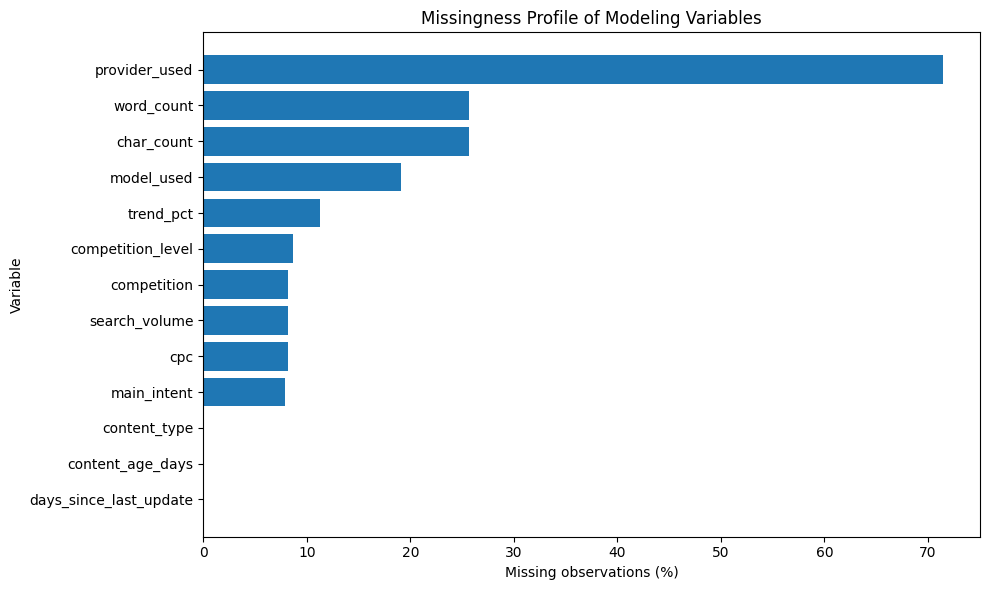

In [10]:
# ============================================================
# 4.1 Missingness profile
# ============================================================

missing = (
    df[FEATURES + [TARGET]]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.barh(missing.index[::-1], missing.values[::-1])
plt.xlabel("Missing observations (%)")
plt.ylabel("Variable")
plt.title("Missingness Profile of Modeling Variables")
plt.tight_layout()
plt.show()


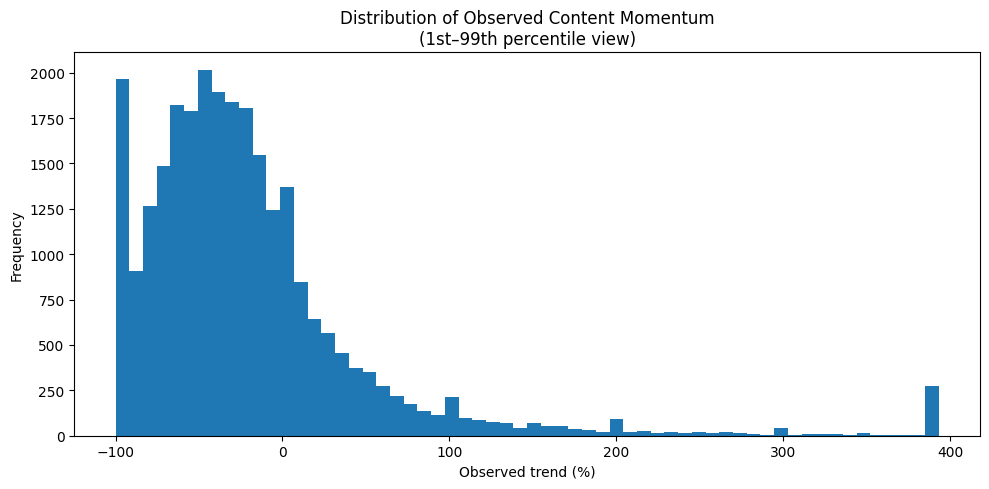

In [11]:
# ============================================================
# 4.2 Target distribution
# ============================================================

target_plot = y.clip(
    lower=y.quantile(0.01),
    upper=y.quantile(0.99)
)

plt.figure(figsize=(10, 5))
plt.hist(target_plot, bins=60)
plt.xlabel("Observed trend (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Observed Content Momentum\n(1st–99th percentile view)")
plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# 4.3 Target descriptive statistics
# ============================================================

target_summary = pd.DataFrame({
    "metric": [
        "n",
        "mean",
        "median",
        "std",
        "min",
        "p01",
        "p25",
        "p75",
        "p99",
        "max",
    ],
    "value": [
        y.count(),
        y.mean(),
        y.median(),
        y.std(),
        y.min(),
        y.quantile(.01),
        y.quantile(.25),
        y.quantile(.75),
        y.quantile(.99),
        y.max(),
    ]
})

display(target_summary)
target_summary.to_csv(
    OUTPUT_DIR / "target_summary.csv",
    index=False
)


,metric,value
0,n,26612.000000
1,mean,-4.785969
2,median,-33.500000
3,std,473.861780
4,min,-100.000000
5,p01,-100.000000
6,p25,-62.600000
7,p75,0.000000
8,p99,393.246000
9,max,44900.000000


# 5. Grouped Validation Design

The primary split is grouped by anonymized client.

This is more conservative than a naive random row split because observations from the same client are not allowed to appear in both training and test data.

The purpose is to estimate whether relationships generalize across unseen client groups rather than merely across randomly selected rows.


In [13]:
# ============================================================
# 5.1 Grouped train/test split
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups,
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))
print("Unique training clients/groups:", groups_train.nunique())
print("Unique testing clients/groups :", groups_test.nunique())

overlap = set(groups_train.dropna()).intersection(
    set(groups_test.dropna())
)

print("Client/group overlap:", len(overlap))

assert len(overlap) == 0, "Grouped split leakage detected."


Training rows: 21514
Testing rows : 5098
Unique training clients/groups: 24
Unique testing clients/groups : 7
Client/group overlap: 0


# 6. Leakage-Safe Preprocessing

Missing-value imputation and scaling are embedded inside model pipelines. Consequently, all preprocessing parameters are learned from the training partition only.

This prevents the test distribution from influencing preprocessing.


In [14]:
# ============================================================
# 6.1 Preprocessing pipeline
# ============================================================

transformers = []

if NUMERIC_FEATURES:
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    transformers.append(
        ("numeric", numeric_pipeline, NUMERIC_FEATURES)
    )

if CATEGORICAL_FEATURES:
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=5,
            )
        ),
    ])

    transformers.append(
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES)
    )

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
)


# 7. Model Benchmark

The benchmark contains:

- **Dummy Regressor:** irreducible baseline representing mean-only prediction.
- **Ridge Regression:** regularized linear reference model.
- **Random Forest:** nonlinear ensemble capable of interaction effects.
- **Extra Trees:** highly randomized tree ensemble.

The objective is not to crown a sophisticated algorithm by default. The correct model is the one that demonstrates the strongest out-of-sample evidence under the predefined validation protocol.


In [15]:
# ============================================================
# 7.1 Candidate models
# ============================================================

models = {
    "Dummy Regressor": Pipeline([
        ("preprocess", preprocessor),
        ("model", DummyRegressor(strategy="mean")),
    ]),

    "Ridge Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", Ridge(alpha=10.0)),
    ]),

    "Random Forest": Pipeline([
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=10,
                max_features=0.8,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),
    ]),

    "Extra Trees": Pipeline([
        ("preprocess", preprocessor),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                min_samples_leaf=10,
                max_features=0.8,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),
    ]),
}


In [16]:
# ============================================================
# 7.2 Fit and evaluate
# ============================================================

results = []
fitted_models = {}
predictions = {}

for name, model in models.items():

    print(f"Fitting {name}...")

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

    fitted_models[name] = model
    predictions[name] = pred

results_df = (
    pd.DataFrame(results)
    .sort_values(["MAE", "RMSE"], ascending=[True, True])
    .reset_index(drop=True)
)

display(
    results_df.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}",
    })
)

results_df.to_csv(
    OUTPUT_DIR / "model_comparison.csv",
    index=False
)


Fitting Dummy Regressor...
Fitting Ridge Regression...
Fitting Random Forest...
Fitting Extra Trees...


,Model,MAE,RMSE,R2
0,Dummy Regressor,65.4752,295.9562,-0.0005
1,Ridge Regression,71.3596,297.5412,-0.0113
2,Random Forest,88.6801,309.0226,-0.0908
3,Extra Trees,88.9691,309.3702,-0.0933


## Interpretation protocol

The model comparison is judged on held-out performance.

A sophisticated model is **not** considered successful merely because it produces a visually plausible ranking. If it fails to outperform the dummy baseline, that negative result is retained as a substantive research finding.


In [17]:
# ============================================================
# 7.3 Benchmark decision
# ============================================================

dummy_row = results_df.loc[
    results_df["Model"] == "Dummy Regressor"
].iloc[0]

non_dummy = results_df[
    results_df["Model"] != "Dummy Regressor"
]

best_ml = non_dummy.sort_values("MAE", ascending=True).iloc[0]

print("Best non-dummy model:", best_ml["Model"])
print("Best non-dummy MAE:", best_ml["MAE"])
print("Dummy MAE:", dummy_row["MAE"])

if best_ml["MAE"] < dummy_row["MAE"]:
    predictive_conclusion = (
        "At least one machine-learning model improves on the mean baseline "
        "under grouped held-out validation."
    )
else:
    predictive_conclusion = (
        "No machine-learning model improves on the mean baseline under "
        "grouped held-out validation. The predictive result is therefore "
        "treated as a negative/limited-signal finding."
    )

print("\nResearch conclusion:")
print(predictive_conclusion)


Best non-dummy model: Ridge Regression
Best non-dummy MAE: 71.35958123500593
Dummy MAE: 65.47519352676022

Research conclusion:
No machine-learning model improves on the mean baseline under grouped held-out validation. The predictive result is therefore treated as a negative/limited-signal finding.


# 8. Model Performance Visualization

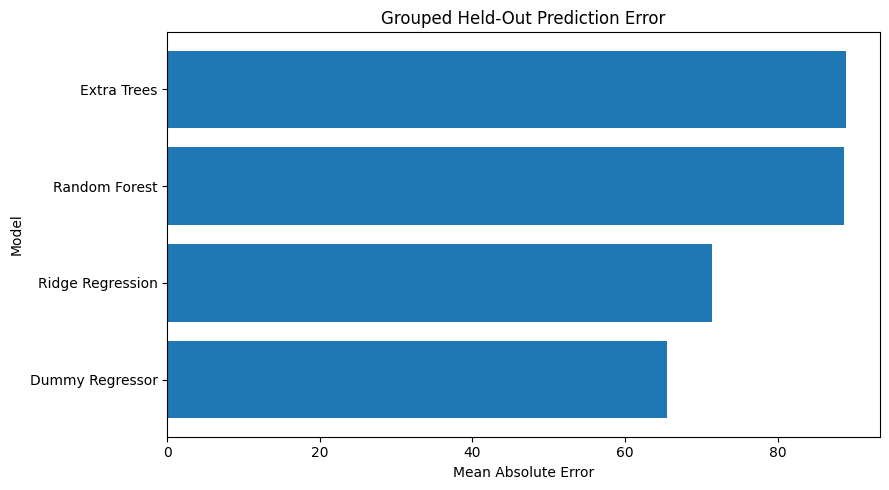

In [18]:
# ============================================================
# 8.1 MAE comparison
# ============================================================

plot_df = results_df.sort_values("MAE", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Model"], plot_df["MAE"])
plt.xlabel("Mean Absolute Error")
plt.ylabel("Model")
plt.title("Grouped Held-Out Prediction Error")
plt.tight_layout()
plt.show()


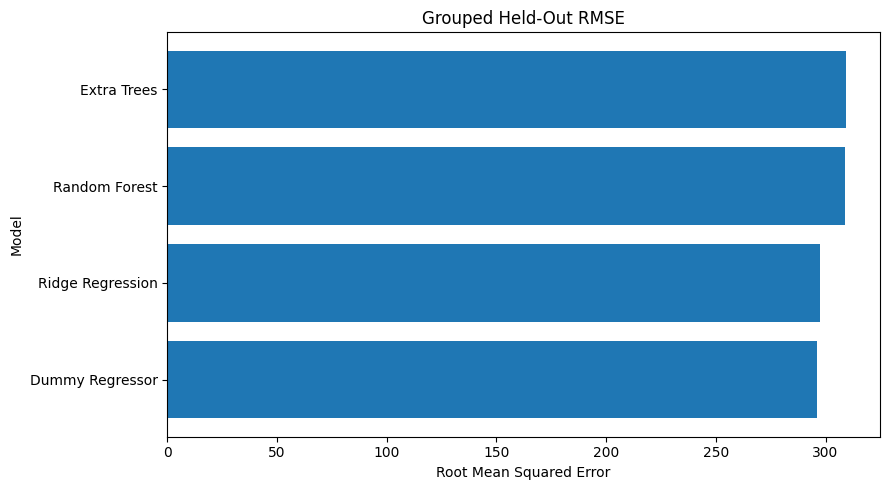

In [19]:
# ============================================================
# 8.2 RMSE comparison
# ============================================================

plot_df = results_df.sort_values("RMSE", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Model"], plot_df["RMSE"])
plt.xlabel("Root Mean Squared Error")
plt.ylabel("Model")
plt.title("Grouped Held-Out RMSE")
plt.tight_layout()
plt.show()


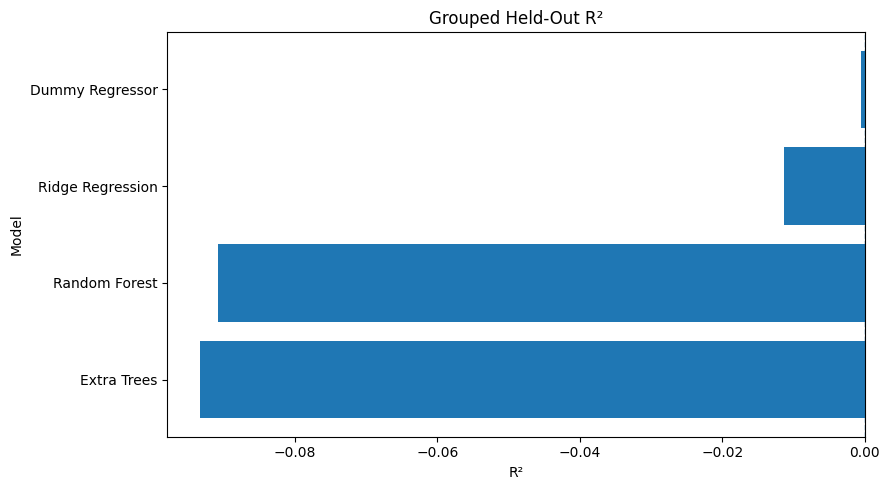

In [20]:
# ============================================================
# 8.3 R² comparison
# ============================================================

plot_df = results_df.sort_values("R2")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Model"], plot_df["R2"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("R²")
plt.ylabel("Model")
plt.title("Grouped Held-Out R²")
plt.tight_layout()
plt.show()


# 9. Diagnostic Analysis of the Exploratory Ranking Model

The Random Forest is retained as an exploratory nonlinear ranking model, regardless of whether it wins the predictive benchmark.

This is an explicit methodological separation:

**Prediction claim:** determined by held-out benchmark metrics.

**Ranking utility:** used to generate relative prioritization signals for human review and is not represented as a validated forecast.


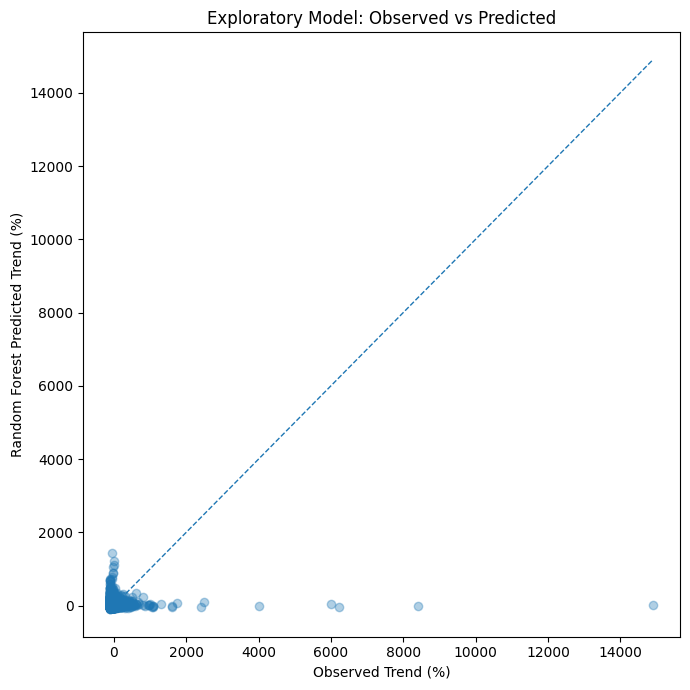

In [21]:
# ============================================================
# 9.1 Random Forest diagnostic predictions
# ============================================================

ranking_model = fitted_models["Random Forest"]
rf_pred = predictions["Random Forest"]

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.35
)

lower = min(y_test.min(), rf_pred.min())
upper = max(y_test.max(), rf_pred.max())

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1
)

plt.xlabel("Observed Trend (%)")
plt.ylabel("Random Forest Predicted Trend (%)")
plt.title("Exploratory Model: Observed vs Predicted")
plt.tight_layout()
plt.show()


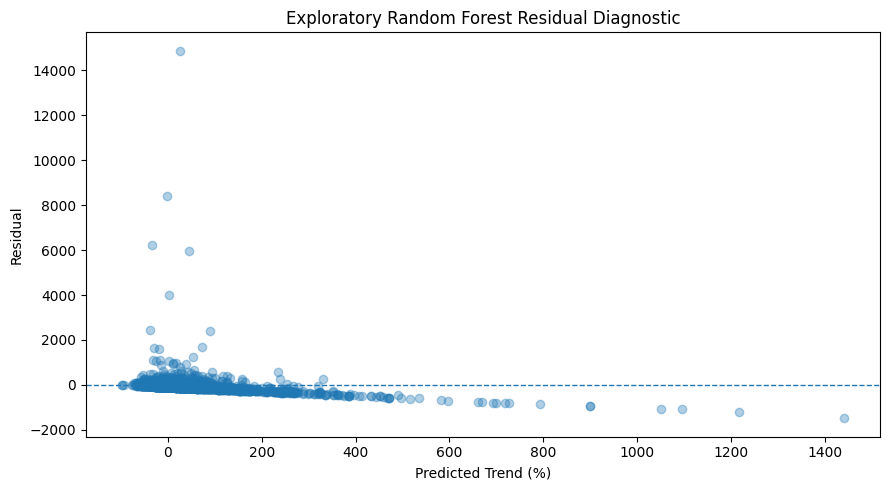

In [22]:
# ============================================================
# 9.2 Residual diagnostic
# ============================================================

residuals = y_test - rf_pred

plt.figure(figsize=(9, 5))
plt.scatter(
    rf_pred,
    residuals,
    alpha=0.35
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Predicted Trend (%)")
plt.ylabel("Residual")
plt.title("Exploratory Random Forest Residual Diagnostic")
plt.tight_layout()
plt.show()


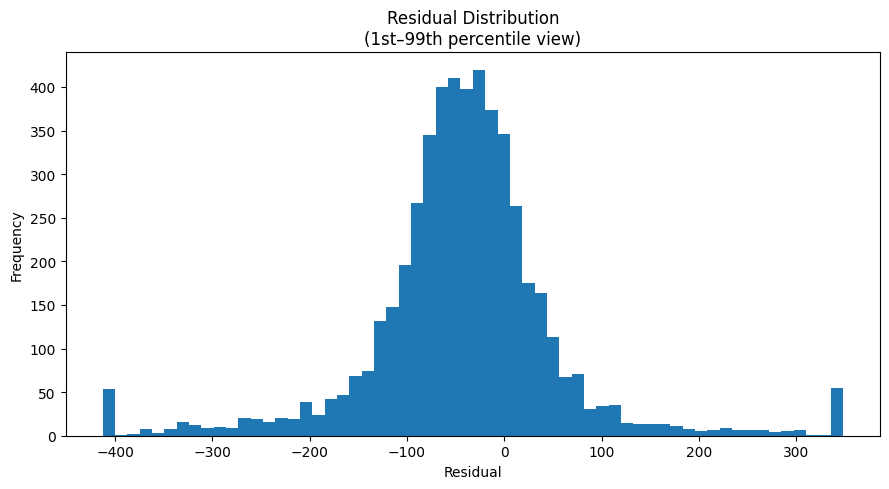

In [23]:
# ============================================================
# 9.3 Residual distribution
# ============================================================

residual_plot = residuals.clip(
    lower=residuals.quantile(0.01),
    upper=residuals.quantile(0.99),
)

plt.figure(figsize=(9, 5))
plt.hist(residual_plot, bins=60)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution\n(1st–99th percentile view)")
plt.tight_layout()
plt.show()


# 10. Permutation Importance

Permutation importance is calculated on the untouched test set rather than relying on tree impurity importance. This provides a more defensible estimate of how much predictive information is lost when a feature is disrupted.

Importantly, feature importance is interpreted as **associational**, not causal.


In [24]:
# ============================================================
# 10.1 Permutation importance
# ============================================================

perm = permutation_importance(
    ranking_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

display(importance_df)

importance_df.to_csv(
    OUTPUT_DIR / "permutation_importance.csv",
    index=False
)


,feature,importance_mean,importance_std
3,word_count,10.925458,0.520312
0,search_volume,10.855314,0.973300
4,char_count,5.447605,0.413041
1,competition,3.428014,0.381740
6,days_since_last_update,2.959371,0.262951
2,cpc,2.074102,0.207187
5,content_age_days,1.845638,0.945165
10,provider_used,0.022146,0.001481
7,competition_level,-0.088470,0.027482
9,main_intent,-0.440405,0.189133


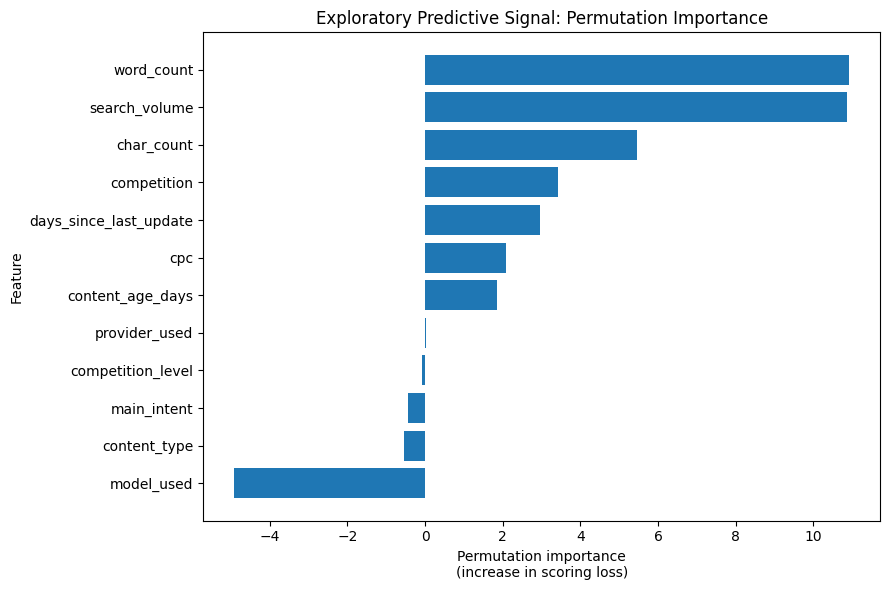

In [25]:
# ============================================================
# 10.2 Feature importance plot
# ============================================================

top_importance = importance_df.head(12).sort_values(
    "importance_mean"
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_importance["feature"],
    top_importance["importance_mean"]
)
plt.xlabel("Permutation importance\n(increase in scoring loss)")
plt.ylabel("Feature")
plt.title("Exploratory Predictive Signal: Permutation Importance")
plt.tight_layout()
plt.show()


# 11. Exploratory Content Opportunity Engine

Because the predictive benchmark may not demonstrate reliable future forecasting power, the operational layer is intentionally transparent.

The opportunity engine does **not** claim that a page will improve after refresh. It estimates relative review priority using observable signals:

- search demand
- competition
- content staleness
- content lifecycle

These components are normalized within the available dataset and combined into an interpretable score.

The score is a **review-prioritization index**, not a probability.


In [26]:
# ============================================================
# 11.1 Build interpretable opportunity components
# ============================================================

ranking_df = df.copy()

core_opportunity_columns = [
    "search_volume",
    "days_since_last_update",
    "content_age_days",
]

missing_core = [
    c for c in core_opportunity_columns
    if c not in ranking_df.columns
]

if missing_core:
    raise KeyError(
        "The opportunity engine requires these missing columns: "
        + ", ".join(missing_core)
    )

ranking_df = ranking_df.dropna(
    subset=core_opportunity_columns
).copy()

def percentile_rank(series):
    return series.rank(
        method="average",
        pct=True
    )

# Demand component
ranking_df["demand_signal"] = percentile_rank(
    ranking_df["search_volume"]
)

# Staleness component
ranking_df["staleness_signal"] = percentile_rank(
    ranking_df["days_since_last_update"]
)

# Lifecycle component
ranking_df["age_signal"] = percentile_rank(
    ranking_df["content_age_days"]
)

# Competition component
if "competition" in ranking_df.columns:
    ranking_df["competition_signal"] = percentile_rank(
        ranking_df["competition"]
    )
else:
    ranking_df["competition_signal"] = 0.5

# Weighted review-priority index
ranking_df["opportunity_score"] = (
    0.40 * ranking_df["demand_signal"]
    + 0.30 * ranking_df["staleness_signal"]
    + 0.20 * ranking_df["competition_signal"]
    + 0.10 * ranking_df["age_signal"]
) * 100

print(f"Rows eligible for opportunity scoring: {len(ranking_df):,}")


Rows eligible for opportunity scoring: 27,532


## 11.2 Transparent diagnostic reason codes

Reason codes are deliberately rule-based. They are not presented as model explanations and do not imply causality.


In [27]:
# ============================================================
# 11.2 Reason codes
# ============================================================

demand_q75 = ranking_df["search_volume"].quantile(0.75)
stale_q75 = ranking_df["days_since_last_update"].quantile(0.75)
age_q75 = ranking_df["content_age_days"].quantile(0.75)

def reason_code(row):
    reasons = []

    if row["days_since_last_update"] >= stale_q75:
        reasons.append("Stale Content")

    if row["search_volume"] >= demand_q75:
        reasons.append("High Search Demand")

    if row["content_age_days"] >= age_q75:
        reasons.append("Mature Content")

    if not reasons:
        reasons.append("General Optimization Signal")

    return " + ".join(reasons[:2])

ranking_df["reason_code"] = ranking_df.apply(
    reason_code,
    axis=1
)


# 12. Action Prioritization

The labels below deliberately use "review" language rather than autonomous action language.

This aligns the operational output with the evidence level of the study.


In [28]:
# ============================================================
# 12.1 Priority labels
# ============================================================

q80 = ranking_df["opportunity_score"].quantile(0.80)
q50 = ranking_df["opportunity_score"].quantile(0.50)

ranking_df["recommended_action"] = np.select(
    [
        ranking_df["opportunity_score"] >= q80,
        ranking_df["opportunity_score"] >= q50,
    ],
    [
        "High Priority Review",
        "Review",
    ],
    default="Monitor",
)

ranking_df = ranking_df.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

ranking_df["rank"] = np.arange(
    1,
    len(ranking_df) + 1
)


In [29]:
# ============================================================
# 12.2 Top 20 recommendations
# ============================================================

top_columns = [
    "rank",
    "opportunity_score",
    "recommended_action",
    "reason_code",
    "search_volume",
    "competition",
    "content_age_days",
    "days_since_last_update",
    "content_type",
    "main_intent",
]

top_columns = [
    c for c in top_columns
    if c in ranking_df.columns
]

top_20 = ranking_df.head(20)[top_columns].copy()

display(
    top_20.style.format({
        "opportunity_score": "{:.2f}",
        "search_volume": "{:,.0f}",
        "competition": "{:.2f}",
        "content_age_days": "{:.0f}",
        "days_since_last_update": "{:.0f}",
    })
)

top_20.to_csv(
    OUTPUT_DIR / "top_20_content_opportunities.csv",
    index=False
)


,rank,opportunity_score,recommended_action,reason_code,search_volume,competition,content_age_days,days_since_last_update,content_type,main_intent
0,1,93.12,High Priority Review,Stale Content + High Search Demand,"9,900",0.69,545,104,keyword article,informational
1,2,93.12,High Priority Review,Stale Content + High Search Demand,"3,600",0.76,545,104,keyword article,informational
2,3,92.98,High Priority Review,Stale Content + High Search Demand,"14,800",0.95,463,104,keyword article,informational
3,4,92.64,High Priority Review,Stale Content + High Search Demand,"6,600",0.57,537,104,keyword article,informational
4,5,92.57,High Priority Review,Stale Content + High Search Demand,"3,600",0.90,463,104,keyword article,informational
5,6,92.31,High Priority Review,Stale Content + High Search Demand,"22,200",0.44,545,104,keyword article,informational
6,7,92.21,High Priority Review,Stale Content + High Search Demand,"4,400",1.00,362,104,keyword article,transactional
7,8,92.15,High Priority Review,Stale Content + High Search Demand,"3,600",1.00,362,104,keyword article,commercial
8,9,92.15,High Priority Review,Stale Content + High Search Demand,"3,600",1.00,362,104,keyword article,transactional
9,10,92.07,High Priority Review,Stale Content + High Search Demand,"2,900",1.00,362,104,keyword article,informational


# 13. Opportunity Engine Visualization

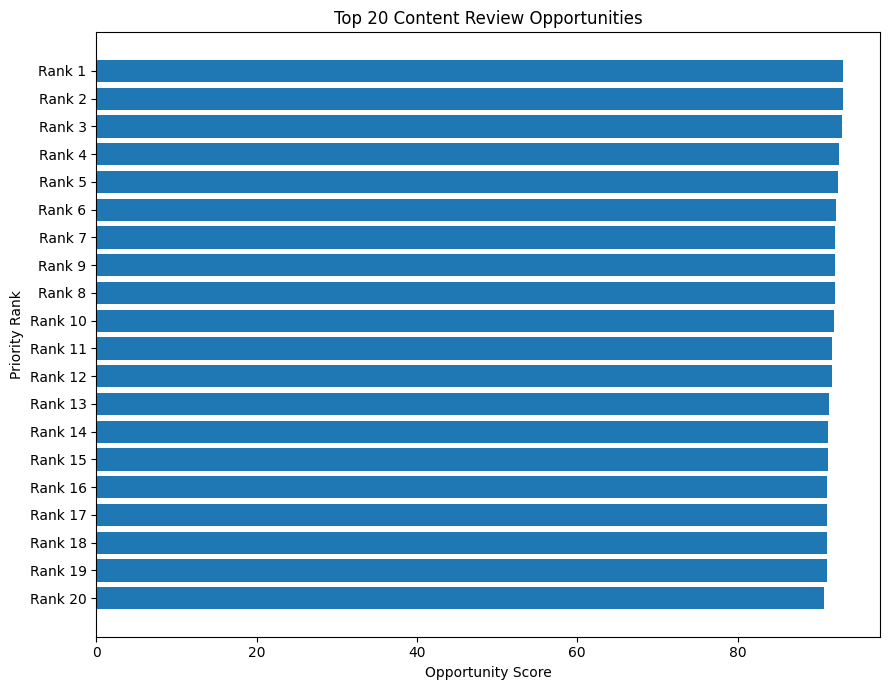

In [30]:
# ============================================================
# 13.1 Top-20 opportunity signals
# ============================================================

plot_top = ranking_df.head(20).sort_values(
    "opportunity_score"
)

plt.figure(figsize=(9, 7))
plt.barh(
    range(len(plot_top)),
    plot_top["opportunity_score"]
)
plt.yticks(
    range(len(plot_top)),
    [f"Rank {r}" for r in plot_top["rank"]]
)
plt.xlabel("Opportunity Score")
plt.ylabel("Priority Rank")
plt.title("Top 20 Content Review Opportunities")
plt.tight_layout()
plt.show()


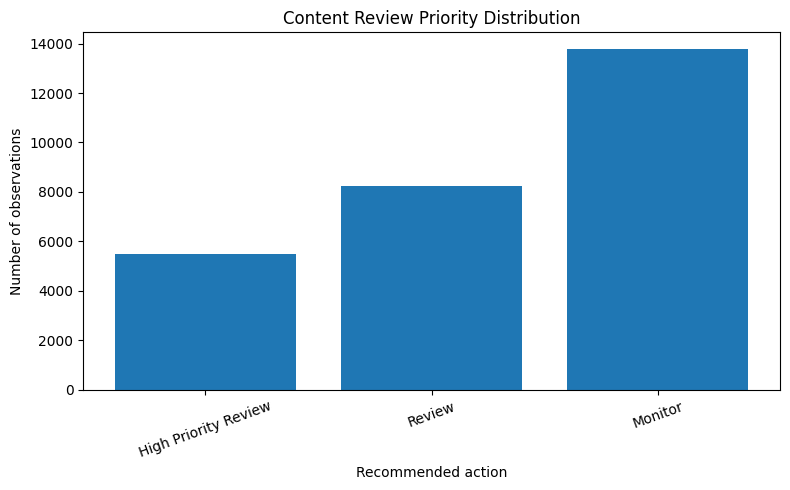

In [31]:
# ============================================================
# 13.2 Action distribution
# ============================================================

action_order = [
    "High Priority Review",
    "Review",
    "Monitor",
]

action_counts = (
    ranking_df["recommended_action"]
    .value_counts()
    .reindex(action_order, fill_value=0)
)

plt.figure(figsize=(8, 5))
plt.bar(
    action_counts.index,
    action_counts.values
)
plt.xlabel("Recommended action")
plt.ylabel("Number of observations")
plt.title("Content Review Priority Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


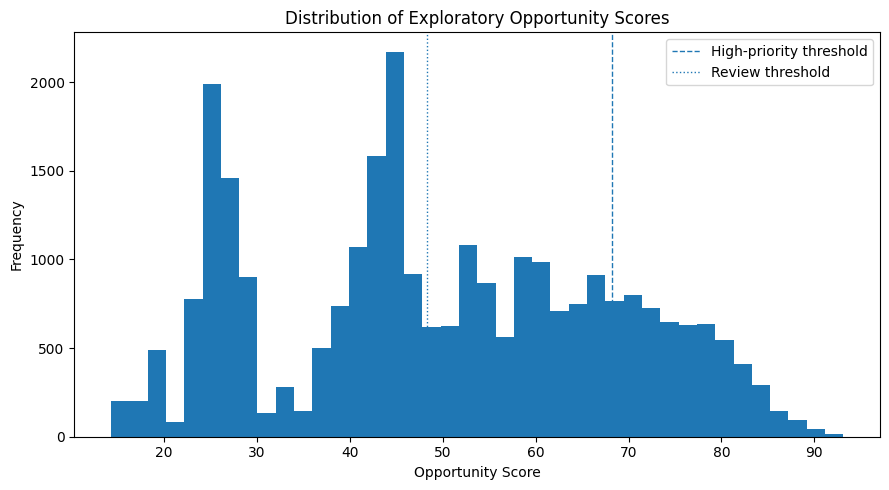

In [32]:
# ============================================================
# 13.3 Opportunity-score distribution
# ============================================================

plt.figure(figsize=(9, 5))
plt.hist(
    ranking_df["opportunity_score"],
    bins=40
)
plt.axvline(
    q80,
    linestyle="--",
    linewidth=1,
    label="High-priority threshold"
)
plt.axvline(
    q50,
    linestyle=":",
    linewidth=1,
    label="Review threshold"
)
plt.xlabel("Opportunity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Exploratory Opportunity Scores")
plt.legend()
plt.tight_layout()
plt.show()


# 14. Subgroup Analysis

A ranking framework should not be interpreted only at the aggregate level. This section examines whether opportunity signals differ systematically across content type and search intent.

This is descriptive analysis, not a causal comparison.


In [33]:
# ============================================================
# 14.1 Content-type summary
# ============================================================

if "content_type" in ranking_df.columns:
    content_type_summary = (
        ranking_df.groupby("content_type")
        .agg(
            pages=("opportunity_score", "size"),
            mean_score=("opportunity_score", "mean"),
            median_score=("opportunity_score", "median"),
            mean_staleness=("days_since_last_update", "mean"),
            mean_demand=("search_volume", "mean"),
        )
        .sort_values("mean_score", ascending=False)
    )

    display(content_type_summary)

    content_type_summary.to_csv(
        OUTPUT_DIR / "content_type_summary.csv"
    )
else:
    print("content_type not available; subgroup analysis skipped.")


,pages,mean_score,median_score,mean_staleness,mean_demand
content_type,,,,,
keyword article,26835,50.628588,49.289917,47.833352,163.00913
comparison article,697,25.870659,27.138966,18.010043,0.00000


In [34]:
# ============================================================
# 14.2 Search-intent summary
# ============================================================

if "main_intent" in ranking_df.columns:
    intent_summary = (
        ranking_df.groupby("main_intent")
        .agg(
            pages=("opportunity_score", "size"),
            mean_score=("opportunity_score", "mean"),
            median_score=("opportunity_score", "median"),
            mean_staleness=("days_since_last_update", "mean"),
            mean_demand=("search_volume", "mean"),
        )
        .sort_values("mean_score", ascending=False)
    )

    display(intent_summary)

    intent_summary.to_csv(
        OUTPUT_DIR / "search_intent_summary.csv"
    )
else:
    print("main_intent not available; subgroup analysis skipped.")


,pages,mean_score,median_score,mean_staleness,mean_demand
main_intent,,,,,
transactional,5691,59.952891,59.619352,52.918116,90.678264
commercial,4561,58.534534,58.493571,50.689542,166.945845
navigational,46,54.009856,57.868299,41.021739,63.043478
informational,17092,44.551994,43.590912,44.220571,181.018020


# 15. Robustness / Sensitivity Check

A strong research paper should demonstrate that the conclusion is not an artifact of one arbitrary random split.

A secondary random split is therefore used as a sensitivity analysis. It is explicitly secondary because grouped validation remains the primary estimate.


In [35]:
# ============================================================
# 15.1 Secondary random split
# ============================================================

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

sensitivity_model = Pipeline([
    ("preprocess", preprocessor),
    (
        "model",
        ExtraTreesRegressor(
            n_estimators=300,
            min_samples_leaf=10,
            max_features=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),
])

sensitivity_model.fit(
    X_train_r,
    y_train_r
)

sensitivity_pred = sensitivity_model.predict(X_test_r)

grouped_extra_trees = results_df.loc[
    results_df["Model"] == "Extra Trees"
].iloc[0]

sensitivity_results = pd.DataFrame({
    "validation_design": [
        "Grouped by client",
        "Random row split",
    ],
    "MAE": [
        grouped_extra_trees["MAE"],
        mean_absolute_error(y_test_r, sensitivity_pred),
    ],
    "RMSE": [
        grouped_extra_trees["RMSE"],
        np.sqrt(mean_squared_error(y_test_r, sensitivity_pred)),
    ],
    "R2": [
        grouped_extra_trees["R2"],
        r2_score(y_test_r, sensitivity_pred),
    ],
})

display(
    sensitivity_results.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}",
    })
)

sensitivity_results.to_csv(
    OUTPUT_DIR / "validation_sensitivity.csv",
    index=False
)


,validation_design,MAE,RMSE,R2
0,Grouped by client,88.9691,309.3702,-0.0933
1,Random row split,64.7979,317.9670,-0.0128


# 16. Final Research Summary

The final narrative must be generated from observed evidence rather than predetermined success language.


In [36]:
# ============================================================
# 16.1 Evidence summary
# ============================================================

best_non_dummy = results_df[
    results_df["Model"] != "Dummy Regressor"
].sort_values("MAE").iloc[0]

dummy_mae = results_df.loc[
    results_df["Model"] == "Dummy Regressor",
    "MAE"
].iloc[0]

improvement = (
    (dummy_mae - best_non_dummy["MAE"])
    / dummy_mae
) * 100

print("=" * 72)
print("CAPSTONE RESEARCH SUMMARY")
print("=" * 72)

print(f"\nDataset: {len(df):,} rows × {df.shape[1]} columns")
print(f"Modeling observations: {len(model_df):,}")
print(f"Predictive features: {len(FEATURES)}")
print("Primary validation: grouped by anonymized client")
print("Random seed:", RANDOM_STATE)

print("\nBest non-dummy model:")
print(best_non_dummy["Model"])

print("\nBest non-dummy MAE:")
print(f"{best_non_dummy['MAE']:.4f}")

print("\nDummy baseline MAE:")
print(f"{dummy_mae:.4f}")

print("\nRelative MAE improvement vs dummy:")
print(f"{improvement:.2f}%")

print("\nResearch interpretation:")
print(predictive_conclusion)

print("\nOperational interpretation:")
print(
    "The opportunity engine should be used to prioritize human review, "
    "not to guarantee future traffic, ranking, click, or business outcomes."
)


CAPSTONE RESEARCH SUMMARY

Dataset: 30,000 rows × 44 columns
Modeling observations: 26,612
Predictive features: 12
Primary validation: grouped by anonymized client
Random seed: 42

Best non-dummy model:
Ridge Regression

Best non-dummy MAE:
71.3596

Dummy baseline MAE:
65.4752

Relative MAE improvement vs dummy:
-8.99%

Research interpretation:
No machine-learning model improves on the mean baseline under grouped held-out validation. The predictive result is therefore treated as a negative/limited-signal finding.

Operational interpretation:
The opportunity engine should be used to prioritize human review, not to guarantee future traffic, ranking, click, or business outcomes.


# 17. Reproducibility & Artifact Export

The following files are produced for the research repository.

No private identifiers are intentionally exported in the recommendation table. The export is limited to public-safe analytical fields.


In [37]:
# ============================================================
# 17.1 Public-safe recommendation export
# ============================================================

safe_export_columns = [
    "rank",
    "opportunity_score",
    "recommended_action",
    "reason_code",
    "search_volume",
    "competition",
    "content_age_days",
    "days_since_last_update",
    "content_type",
    "main_intent",
]

safe_export_columns = [
    c for c in safe_export_columns
    if c in ranking_df.columns
]

safe_recommendations = ranking_df[
    safe_export_columns
].copy()

safe_recommendations.to_csv(
    OUTPUT_DIR / "content_opportunity_rankings.csv",
    index=False
)

print("Saved:", OUTPUT_DIR / "content_opportunity_rankings.csv")


Saved: /content/capstone_outputs/content_opportunity_rankings.csv


# 18. Final Quality Gates

These assertions are intentionally strict. A capstone should fail loudly when a methodological condition is violated rather than silently producing a polished but invalid result.


In [38]:
# ============================================================
# 18.1 Final quality gates
# ============================================================

# Target must not be a feature.
assert TARGET not in FEATURES

# Identifiers must not be features.
assert "content_id" not in FEATURES
assert "client_id" not in FEATURES

# Direct target-derived fields must not be features.
for leakage_column in [
    "impressions_last_30d",
    "impressions_prev_30d",
    "trend_direction",
]:
    assert leakage_column not in FEATURES

# Grouped split must contain no client/group overlap.
assert len(overlap) == 0

# Results must contain all expected metrics.
assert set(["Model", "MAE", "RMSE", "R2"]).issubset(
    results_df.columns
)

# Recommendation ranking must be descending.
assert ranking_df["opportunity_score"].is_monotonic_decreasing

# Top-20 must be available when enough rows exist.
assert len(top_20) == min(20, len(ranking_df))

print("\n" + "=" * 72)
print("ALL QUALITY GATES PASSED")
print("=" * 72)

print("\nRecommended repository artifacts:")
for file in sorted(OUTPUT_DIR.glob("*")):
    print(" -", file.name)



ALL QUALITY GATES PASSED

Recommended repository artifacts:
 - content_opportunity_rankings.csv
 - content_type_summary.csv
 - model_comparison.csv
 - permutation_importance.csv
 - schema_audit.csv
 - search_intent_summary.csv
 - target_summary.csv
 - top_20_content_opportunities.csv
 - validation_sensitivity.csv


# 19. Research Conclusion

The appropriate conclusion is determined by the evidence produced above.

A successful capstone does not require an impressive R². It requires a defensible research question, valid measurement, leakage control, honest validation, reproducible analysis, interpretable outputs, and disciplined claims.

The central contribution of this workflow is therefore twofold:

1. It establishes whether the available historical attributes contain generalizable predictive information for observed content momentum.
2. It converts the available search-intelligence context into a transparent, auditable opportunity-review system without overstating predictive or causal capability.

The resulting system should be presented as a **research-backed decision support layer for content review**, not as an autonomous optimizer or a validated forecast of search performance.


# 20. Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source: FlyRank

This analysis is an independent educational research artifact and does not claim endorsement, causality, access to proprietary ranking algorithms, or prediction of future Google search outcomes.


# 21. Colab Export Checklist

After running all cells, the main public-safe artifacts will be available inside:

`/content/capstone_outputs/`

Key files include:

- `schema_audit.csv`
- `target_summary.csv`
- `model_comparison.csv`
- `permutation_importance.csv`
- `top_20_content_opportunities.csv`
- `content_type_summary.csv` (when available)
- `search_intent_summary.csv` (when available)
- `validation_sensitivity.csv`
- `content_opportunity_rankings.csv`

The notebook is designed to be rerun from top to bottom with the same random seed (`42`).
